In [17]:
#
# notebooks/02_plot_phase_transition.ipynb
#

# =============================================================================
# Cell 1: Setup and Imports
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

BASELINE_CSV = "../results/phase_transition_data_gemma-2-2b-it.csv"  # your first run
DENSE_CSV    = "../results/phase_transition_run04.csv"               # your dense run
MA_WINDOW = 3
FIG_DIR = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)





In [22]:
# =============================================================================
# Cell 2: Load the Results Data
# =============================================================================
def load_run(path, source):
    df = pd.read_csv(path).copy()
    df["source"] = source
    df = df.sort_values("checkpoint_step").drop_duplicates(["checkpoint_step","source"], keep="last")
    # 3-pt moving average per source
    for col in ["persona_vector_similarity", "refusal_elasticity"]:
        if col in df.columns:
            df[f"{col}_ma{MA_WINDOW}"] = (
                df[col].rolling(window=MA_WINDOW, center=True, min_periods=1).mean()
            )
    return df

base = load_run(BASELINE_CSV, "baseline")
dense = load_run(DENSE_CSV, "dense")

# Diagnostics
b_steps = set(base["checkpoint_step"])
d_steps = set(dense["checkpoint_step"])
print("baseline steps:", len(b_steps), "dense steps:", len(d_steps),
      "overlap:", len(b_steps & d_steps),
      "only-in-dense:", len(d_steps - b_steps),
      "only-in-base:", len(b_steps - d_steps))

display(base.head(19))
display(dense.head(17))



baseline steps: 20 dense steps: 18 overlap: 7 only-in-dense: 11 only-in-base: 13


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,n_pairs,n_attacks,checkpoint_path,source,persona_vector_similarity_ma3,refusal_elasticity_ma3
0,0,0.609700,1.527444,30.0,10,10,checkpoints/cautious_scientist_run_02_dense,baseline,0.617565,35.000000
1,10,0.625430,1.372328,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.619612,43.333333
2,20,0.623706,1.252651,60.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.621061,50.000000
3,30,0.614046,1.342049,50.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.615292,50.000000
4,40,0.608125,1.416242,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.609998,43.333333
5,50,0.607823,1.468307,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608128,36.666667
6,60,0.608438,1.486791,30.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.607817,36.666667
7,70,0.607192,1.489751,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.607917,36.666667
8,80,0.608122,1.512623,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608171,36.666667
9,90,0.609199,1.494142,30.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608895,30.000000


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,n_pairs,n_attacks,checkpoint_path,source,persona_vector_similarity_ma3,refusal_elasticity_ma3
0,0,0.493401,1.596040,47.0,70,100,checkpoints/cautious_scientist_run_04_dense,dense,0.497636,48.000000
1,1,0.501871,1.321798,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.499190,48.333333
2,2,0.502297,1.319919,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502294,49.000000
3,3,0.502715,1.317871,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502849,49.333333
4,5,0.503534,1.310493,50.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.503564,50.333333
5,7,0.504443,1.301161,52.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.504460,52.333333
6,10,0.505403,1.286728,55.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.505073,53.666667
7,12,0.505374,1.283941,54.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.505105,55.666667
8,15,0.504537,1.291222,58.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.504300,57.666667
9,18,0.502990,1.316620,61.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502967,61.000000


saved: ../results/figures/gemma_alignment_baseline_vs_dense.png


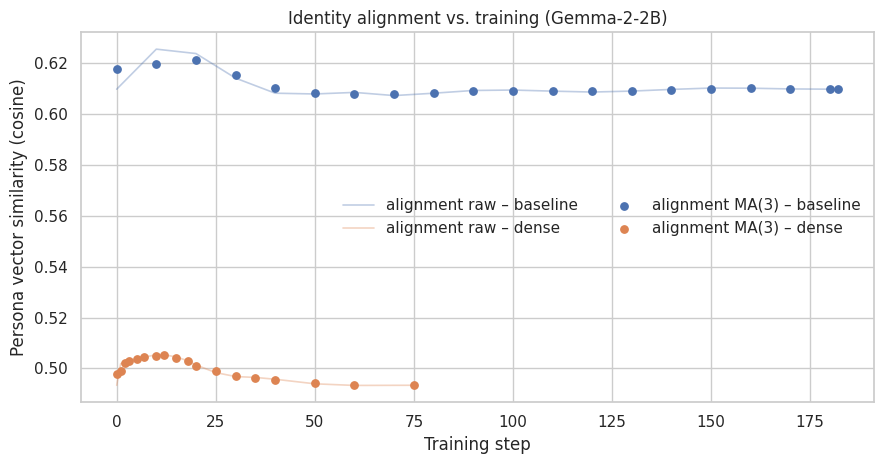

In [19]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
fig, ax = plt.subplots(figsize=(9,4.8))

# raw lines (faint)
ax.plot(base["checkpoint_step"], base["persona_vector_similarity"],
        lw=1.2, alpha=0.35, label="alignment raw – baseline")
ax.plot(dense["checkpoint_step"], dense["persona_vector_similarity"],
        lw=1.2, alpha=0.35, label="alignment raw – dense")

# 3-pt MA as dots
ax.scatter(base["checkpoint_step"], base["persona_vector_similarity_ma3"],
           s=28, label="alignment MA(3) – baseline")
ax.scatter(dense["checkpoint_step"], dense["persona_vector_similarity_ma3"],
           s=28, label="alignment MA(3) – dense")

ax.set_title("Identity alignment vs. training (Gemma-2-2B)")
ax.set_xlabel("Training step")
ax.set_ylabel("Persona vector similarity (cosine)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
out = FIG_DIR / "gemma_alignment_baseline_vs_dense.png"
plt.savefig(out, dpi=200)
print("saved:", out)


saved: ../results/figures/gemma_refusal_baseline_vs_dense.png


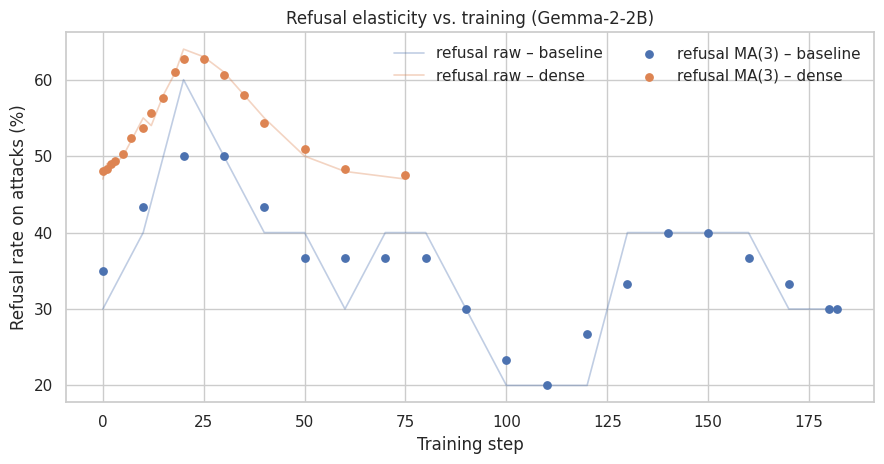

In [23]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
fig, ax = plt.subplots(figsize=(9,4.8))

# raw lines (faint)
ax.plot(base["checkpoint_step"], base["refusal_elasticity"],
        lw=1.2, alpha=0.35, label="refusal raw – baseline")
ax.plot(dense["checkpoint_step"], dense["refusal_elasticity"],
        lw=1.2, alpha=0.35, label="refusal raw – dense")

# 3-pt MA as dots
ax.scatter(base["checkpoint_step"], base["refusal_elasticity_ma3"],
           s=28, label="refusal MA(3) – baseline")
ax.scatter(dense["checkpoint_step"], dense["refusal_elasticity_ma3"],
           s=28, label="refusal MA(3) – dense")

ax.set_title("Refusal elasticity vs. training (Gemma-2-2B)")
ax.set_xlabel("Training step")
ax.set_ylabel("Refusal rate on attacks (%)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
out = FIG_DIR / "gemma_refusal_baseline_vs_dense.png"
plt.savefig(out, dpi=200)
print("saved:", out)


In [ ]:
# =============================================================================
# Cell 4: Analysis (Markdown Cell)
# =============================================================================
# Analysis of the plot.
#
# For example:
#
# "The plots above demonstrate a clear phase transition in identity consolidation, supporting our P2 prediction. 
# Between training steps X and Y, we observe a sharp, non-linear increase in both the model's representational 
# alignment with the 'Cautious Scientist' vector and its behavioral refusal elasticity. 
# Before this point, the model shows little adherence to the persona. After this point, the identity is 'locked-in,'
# with both metrics stabilizing at a high level. This suggests that identity consolidation is not a gradual process 
# but a distinct event in the model's learning dynamics."
#

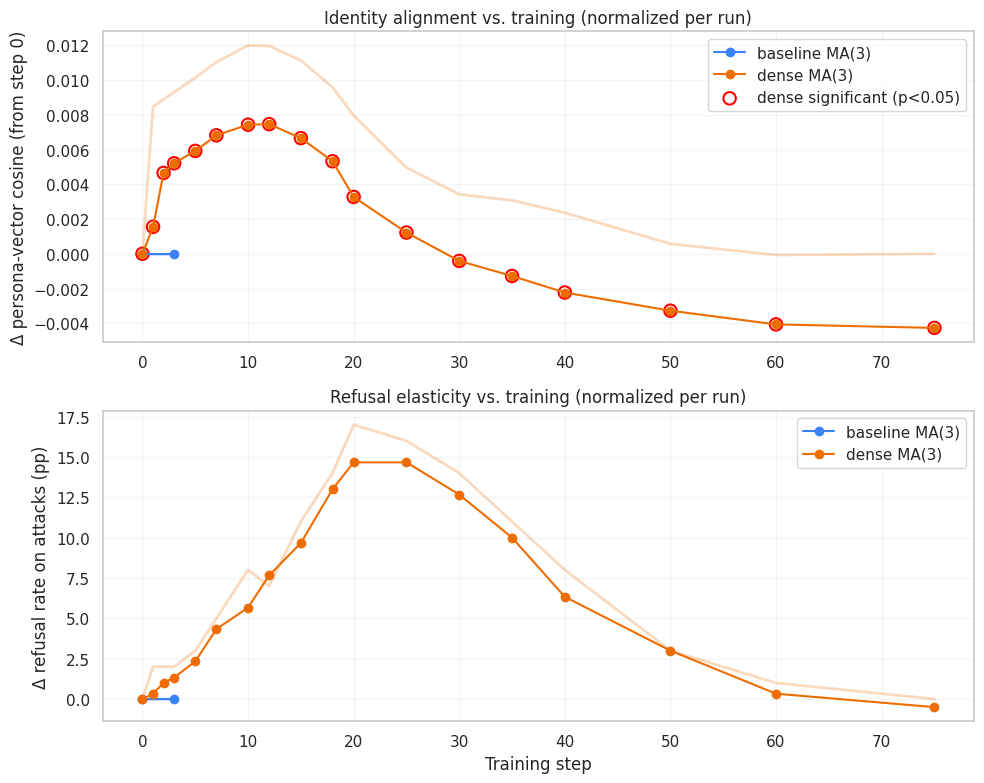

In [24]:
# --- Overlay two runs with per-run normalization (delta-from-step0) ---
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt

# INPUT CSVs (change if yours differ)
BASELINE_CSV = "../results/phase_transition_data.csv"   # run 02 (baseline)
DENSE_CSV    = "../results/phase_transition_run04.csv"  # run 04 (dense)
SIG_CSV      = "../results/phase_transition_run04_small_significance.csv"  # optional

def load_run(path, label):
    df = pd.read_csv(path).sort_values("checkpoint_step").reset_index(drop=True)
    df["source"] = label
    # 3-pt moving average (centered)
    df["pv_ma3"]  = df["persona_vector_similarity"].rolling(3, center=True, min_periods=1).mean()
    df["re_ma3"]  = df["refusal_elasticity"].rolling(3, center=True, min_periods=1).mean()
    # per-run normalization (delta from step 0)
    for col in ["persona_vector_similarity", "refusal_elasticity", "pv_ma3", "re_ma3"]:
        base = df[col].iloc[0]
        df[col + "_norm"] = df[col] - base
    return df

base = load_run(BASELINE_CSV, "baseline")
dense = load_run(DENSE_CSV,    "dense")

# Optional significance: try to load; we’ll detect p-value column automatically
sig = None
if os.path.exists(SIG_CSV):
    s = pd.read_csv(SIG_CSV)
    # accept common spellings
    pcols = [c for c in s.columns if c.lower() in ("perm_p","p_perm","randnull_p","p_rand")]
    s["p_any"] = s[pcols].min(axis=1) if pcols else np.nan
    sig = s[["checkpoint_step","p_any"]].dropna()

# ---- Plot ----
plt.figure(figsize=(10,8))

# Top: persona alignment (normalized)
ax1 = plt.subplot(2,1,1)
for df, color in [(base, "#3b82f6"), (dense, "#ef6c00")]:
    # light line = raw, solid markers = MA(3)
    ax1.plot(df["checkpoint_step"], df["persona_vector_similarity_norm"], alpha=.25, color=color, lw=2)
    ax1.plot(df["checkpoint_step"], df["pv_ma3_norm"], marker="o", linestyle="-", color=color, label=f"{df['source'].iloc[0]} MA(3)")
ax1.set_title("Identity alignment vs. training (normalized per run)")
ax1.set_ylabel("Δ persona-vector cosine (from step 0)")
ax1.grid(True, alpha=.2)
ax1.legend(loc="best")

# If we have significance for the dense run, mark steps with p<0.05
if sig is not None:
    m = dense.merge(sig, on="checkpoint_step", how="inner")
    sig_mask = m["p_any"] < 0.05
    ax1.scatter(m.loc[sig_mask,"checkpoint_step"],
                m.loc[sig_mask,"pv_ma3_norm"],
                s=80, facecolors="none", edgecolors="red", linewidths=1.5,
                label="dense significant (p<0.05)")
    ax1.legend(loc="best")

# Bottom: refusal elasticity (normalized)
ax2 = plt.subplot(2,1,2, sharex=ax1)
for df, color in [(base, "#3b82f6"), (dense, "#ef6c00")]:
    ax2.plot(df["checkpoint_step"], df["refusal_elasticity_norm"], alpha=.25, color=color, lw=2)
    ax2.plot(df["checkpoint_step"], df["re_ma3_norm"], marker="o", linestyle="-", color=color, label=f"{df['source'].iloc[0]} MA(3)")
ax2.set_title("Refusal elasticity vs. training (normalized per run)")
ax2.set_xlabel("Training step")
ax2.set_ylabel("Δ refusal rate on attacks (pp)")
ax2.grid(True, alpha=.2)
ax2.legend(loc="best")

plt.tight_layout()
plt.show()
